<a href="https://colab.research.google.com/github/inigomz/summerdatascienceproject/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA for the customer churn dataset**
* My main goal for this EDA is to discover relationships between the variables before we can come up with any questions
* Understanding the data will allow me to formulate questions about the data

## **PART 1: Understanding the dataset.**

In order to have a complete understanding of the dataset, we must first inspect a few things.
* Print a quick overview of the dataset by calling either the first 5 or last 5 entries of the Pandas DataFrame.
* Print a summary of the dataset. This includes finding data types, and how many columns we will be working with.
* Checking for null/non-null counts
* Print the summary statistics of the numerical columns

1. Create necessary imports and print the last 5 entries of the dataframe (Alternatively, you can print the first 5 entries of the dataframe)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("denisexpsito/telco-customer-churn-ibm")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn-ibm' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn-ibm


In [ ]:
import pandas as pd

# Use the provided direct path to the Excel file
excel_file_path = '/kaggle/input/telco-customer-churn-ibm/Customer_Churn_Dataset.xlsx'

# Read the dataset
df = pd.read_excel(excel_file_path)

# Print the last 5 entries of the dataset.
print(df.tail())

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     StreamingTV StreamingMovies        Contract PaperlessBilling  \
7038         Yes             Yes        One year           

2. Display summary statistics of the numerical data. This will be used for data processing later. For now, we will use this to analyze the dataframe.

In [ ]:
# Print the summary statistics
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  numAdminTickets  \
count    7043.000000  7043.000000     7043.000000      7043.000000   
mean        0.162147    32.371149       64.761692         0.515689   
std         0.368612    24.559481       30.090047         1.275299   
min         0.000000     0.000000       18.250000         0.000000   
25%         0.000000     9.000000       35.500000         0.000000   
50%         0.000000    29.000000       70.350000         0.000000   
75%         0.000000    55.000000       89.850000         0.000000   
max         1.000000    72.000000      118.750000         5.000000   

       numTechTickets  
count     7043.000000  
mean         0.419566  
std          1.250117  
min          0.000000  
25%          0.000000  
50%          0.000000  
75%          0.000000  
max          9.000000  


3. Inspect the data type of each column

In [ ]:
# Inspect the data type
print(df.info())

# Inspect the shape
print(f'Shape: {df.shape}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


What do we know based on this information?
* There are 7043 rows and 23 columns
* SeniorCitizen has a max value of 1. There are no values in between 0 and 1
* There are 22 usable columns. [customerID] May be removed since it is redundant.
* Customer ID is a primary key
* There are 4 numerical variables. The rest are categorical.
* SeniorCitizen column appears to be numerical, but is actually categorical.
* Some of the columns contain strings that have "yes" or "no" as an answer. I should change this to 0 and 1 if I want to use this information in other graphs.

## **Part 2: Processing the data**

In [ ]:
# Convert TotalCharges to numeric, turning errors into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify the change
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# List of columns that contain 'Yes'/'No'
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

# Convert 'Yes' to 1 and 'No' to 0
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Print the first 5 rows to confirm the changes
print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG  Female              0        1           0       1   
1  5575-GNVDE    Male              0        0           0      34   
2  3668-QPYBK    Male              0        0           0       2   
3  7795-CFOCW    Male              0        0           0      45   
4  9237-HQITU  Female              0        0           0       2   

   PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0             0  No phone service             DSL             No  ...   
1             1                No             DSL            Yes  ...   
2             1                No             DSL            Yes  ...   
3             0  No phone service             DSL            Yes  ...   
4             1                No     Fiber optic             No  ...   

  StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No              No  Month-to-month                1   
1          No 

Check for any null values

In [ ]:
# Select only numerical columns for the correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Print the correlation with 'Churn'
print(correlation_matrix['Churn'].sort_values(ascending=False))

Churn               1.000000
numTechTickets      0.357283
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
numAdminTickets    -0.019877
Partner            -0.150448
Dependents         -0.164221
TotalCharges       -0.198324
tenure             -0.352229
Name: Churn, dtype: float64


In [ ]:
# Display the amount of null values for every column in the dataset
print(df.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64


There are no null values in this dataset. Now we check for duplicate values. We will drop the primary key since the information would not be useful to us besides being an identifier.

In [ ]:
# Print and check the number of duplicate rows
print(df.duplicated().sum())

# Print the entry contents
print(df[df.duplicated()])

print('===== DROPPING COLUMN =====')
# Drop the "customerID" column
df.drop(columns=['customerID'], inplace=True)

# Print
print(df.shape)

0
Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, numAdminTickets, numTechTickets, Churn]
Index: []

[0 rows x 23 columns]
===== DROPPING COLUMN =====
(7043, 22)


The dataframe contains no duplicate entries. After dropping customerID, we are left with 22 usable columns.

The next step is to analyze every column to see what type of relationship they have with the target.

In [ ]:
# Analyze the relationship between gender and churn
df.groupby(['gender', 'Churn']).size()


gender  Churn
Female  0        2549
        1         939
Male    0        2625
        1         930
dtype: int64

/tmp/ipykernel_1888/68914658.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_churn.index, y=gender_churn['ChurnRate'], palette='viridis')


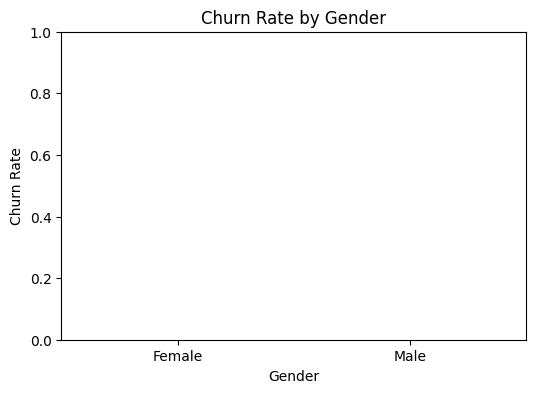

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn rate by gender
gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack()
gender_churn['ChurnRate'] = gender_churn.get('Yes', 0)

# Plotting the churn rate by gender
fig = plt.figure(figsize=(6, 4))
sns.barplot(x=gender_churn.index, y=gender_churn['ChurnRate'], palette='viridis')
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for churn rate
plt.show()

This bar plot visually represents the churn rate for each gender. From the plot, we can observe if there's a significant difference in churn rates between male and female customers.